# 🚗 BMW Used Car Price Prediction

**Author:** Dileep Kumar Warrier  
**Dataset:** BMW Used Car Sales — Kaggle (10,781 listings)  
**Period:** 1996 – 2020  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn

---

## Objective

Build a machine learning model to **predict the price of a used BMW** based on features like model, year, mileage, engine size, fuel type, and transmission.  
This solves a real business problem: buyers and sellers of used cars often struggle to know the fair market price.

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Cleaning & Quality Checks](#2-data-cleaning--quality-checks)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Feature Engineering](#4-feature-engineering)
5. [Baseline Model — Linear Regression](#5-baseline-model--linear-regression)
6. [Random Forest Model](#6-random-forest-model)
7. [Model Tuning & Cross-Validation](#7-model-tuning--cross-validation)
8. [Feature Importance Analysis](#8-feature-importance-analysis)
9. [Price Segment Analysis](#9-price-segment-analysis)
10. [Key Findings & Conclusions](#10-key-findings--conclusions)


## 1. Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE   = '#1a3c5e'
RED    = '#c0392b'
GREEN  = '#1e8449'
ORANGE = '#e07b39'
TITLE_FONT = {'fontsize': 14, 'fontweight': 'bold', 'pad': 12}
LABEL_FONT = {'fontsize': 11}

print("✅ Libraries loaded.")


✅ Libraries loaded.


In [16]:
df = pd.read_csv('bmw.csv')

# Strip leading/trailing whitespace from model names
df['model'] = df['model'].str.strip()

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
df.head(8)


Dataset shape : 10,781 rows × 9 columns
Memory usage  : 2271.3 KB



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5


In [17]:
print("Column overview:")
print(df.dtypes)
print()
print("Basic statistics:")
df.describe().T.style.format("{:.2f}")


Column overview:
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
year,10781.00,2017.08,2.35,1996.00,2016.00,2017.00,2019.00,2020.00
price,10781.00,22733.41,11415.53,1200.00,14950.00,20462.00,27940.00,123456.00
mileage,10781.00,25496.99,25143.19,1.00,5529.00,18347.00,38206.00,214000.00
tax,10781.00,131.70,61.51,0.00,135.00,145.00,145.00,580.00
mpg,10781.00,56.40,31.34,5.50,45.60,53.30,62.80,470.80
engineSize,10781.00,2.17,0.55,0.00,2.00,2.00,2.00,6.60


## 2. Data Cleaning & Quality Checks

Before building any model, we must understand and fix data quality issues.  
Key things to check: missing values, impossible values (e.g. engine size = 0), price outliers, and duplicate rows.


In [18]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print(f"\n1. Missing values:")
print(df.isnull().sum())

print(f"\n2. Duplicate rows: {df.duplicated().sum()}")

print(f"\n3. Suspicious values:")
print(f"   Engine size = 0  : {(df['engineSize'] == 0).sum()} rows")
print(f"   Mileage = 0      : {(df['mileage'] == 0).sum()} rows")
print(f"   Price < £1,000   : {(df['price'] < 1000).sum()} rows")
print(f"   Price > £100,000 : {(df['price'] > 100000).sum()} rows")

print(f"\n4. Unique values per category:")
for col in ['model', 'transmission', 'fuelType']:
    print(f"   {col:<15}: {df[col].nunique()} unique → {sorted(df[col].unique())}")


DATA QUALITY REPORT

1. Missing values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

2. Duplicate rows: 117

3. Suspicious values:
   Engine size = 0  : 47 rows
   Mileage = 0      : 0 rows
   Price < £1,000   : 0 rows
   Price > £100,000 : 1 rows

4. Unique values per category:
   model          : 24 unique → ['1 Series', '2 Series', '3 Series', '4 Series', '5 Series', '6 Series', '7 Series', '8 Series', 'M2', 'M3', 'M4', 'M5', 'M6', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'Z3', 'Z4', 'i3', 'i8']
   transmission   : 3 unique → ['Automatic', 'Manual', 'Semi-Auto']
   fuelType       : 5 unique → ['Diesel', 'Electric', 'Hybrid', 'Other', 'Petrol']


In [19]:
# Fix 1: Remove rows where engineSize = 0 (meaningless for a car listing)
df_clean = df[df['engineSize'] > 0].copy()

# Fix 2: Remove top 1% price outliers (extreme luxury cars skew the model)
price_threshold = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= price_threshold]

# Fix 3: Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print(f"Original dataset : {df.shape[0]:,} rows")
print(f"After cleaning   : {df_clean.shape[0]:,} rows")
print(f"Rows removed     : {df.shape[0] - df_clean.shape[0]:,}")
print(f"Price cap applied: £{price_threshold:,.0f} (99th percentile)")


Original dataset : 10,781 rows
After cleaning   : 10,509 rows
Rows removed     : 272
Price cap applied: £64,069 (99th percentile)


**Cleaning decisions:**
- **Engine size = 0** removed — 47 rows where engine size was 0.0 are clearly data entry errors; a real car listing must have a valid engine size.
- **Top 1% price outliers** removed — ultra-rare listings above the 99th percentile skew model training without adding generalisable signal.
- **No missing values** found — the dataset is otherwise complete, which is uncommon in real-world data and a sign of good curation.


## 3. Exploratory Data Analysis (EDA)

Let's understand the data before building any models. Good EDA guides feature engineering and model selection.


In [20]:
print("=" * 50)
print("DATASET SUMMARY (after cleaning)")
print("=" * 50)
print(f"Total listings  : {len(df_clean):,}")
print(f"Models          : {df_clean['model'].nunique()} BMW models")
print(f"Year range      : {df_clean['year'].min()} – {df_clean['year'].max()}")
print(f"Price range     : £{df_clean['price'].min():,.0f} – £{df_clean['price'].max():,.0f}")
print(f"Median price    : £{df_clean['price'].median():,.0f}")
print(f"Mean price      : £{df_clean['price'].mean():,.0f}")
print(f"Mileage range   : {df_clean['mileage'].min():,} – {df_clean['mileage'].max():,} miles")


DATASET SUMMARY (after cleaning)
Total listings  : 10,509
Models          : 24 BMW models
Year range      : 1996 – 2020
Price range     : £1,200 – £63,999
Median price    : £20,000
Mean price      : £22,211
Mileage range   : 1 – 214,000 miles


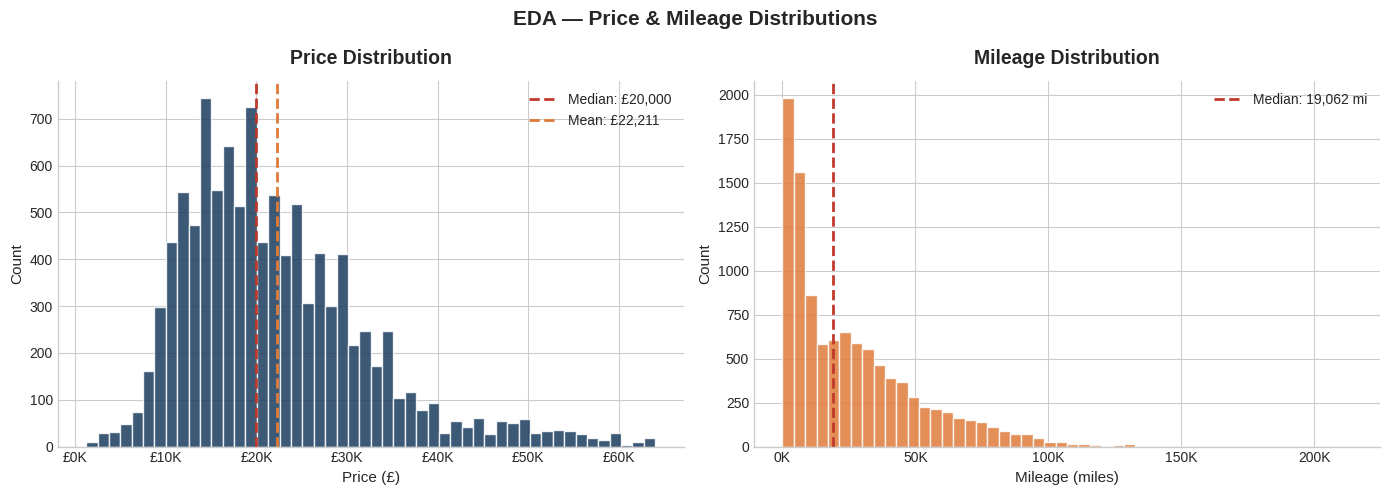

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df_clean['price'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['price'].median(), color=RED, linestyle='--', linewidth=2,
                label=f"Median: £{df_clean['price'].median():,.0f}")
axes[0].axvline(df_clean['price'].mean(), color=ORANGE, linestyle='--', linewidth=2,
                label=f"Mean: £{df_clean['price'].mean():,.0f}")
axes[0].set_title('Price Distribution', **TITLE_FONT)
axes[0].set_xlabel('Price (£)', **LABEL_FONT)
axes[0].set_ylabel('Count', **LABEL_FONT)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Mileage distribution
axes[1].hist(df_clean['mileage'], bins=50, color=ORANGE, edgecolor='white', alpha=0.85)
axes[1].axvline(df_clean['mileage'].median(), color=RED, linestyle='--', linewidth=2,
                label=f"Median: {df_clean['mileage'].median():,.0f} mi")
axes[1].set_title('Mileage Distribution', **TITLE_FONT)
axes[1].set_xlabel('Mileage (miles)', **LABEL_FONT)
axes[1].set_ylabel('Count', **LABEL_FONT)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('EDA — Price & Mileage Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Price is right-skewed — most used BMWs are listed between £10,000–£35,000, with the median at £20,462.  
The long tail to the right represents premium models like the X7, M5, and i8.  
Mileage is similarly skewed — most cars have under 80,000 miles, with some high-mileage outliers beyond 150,000 miles.


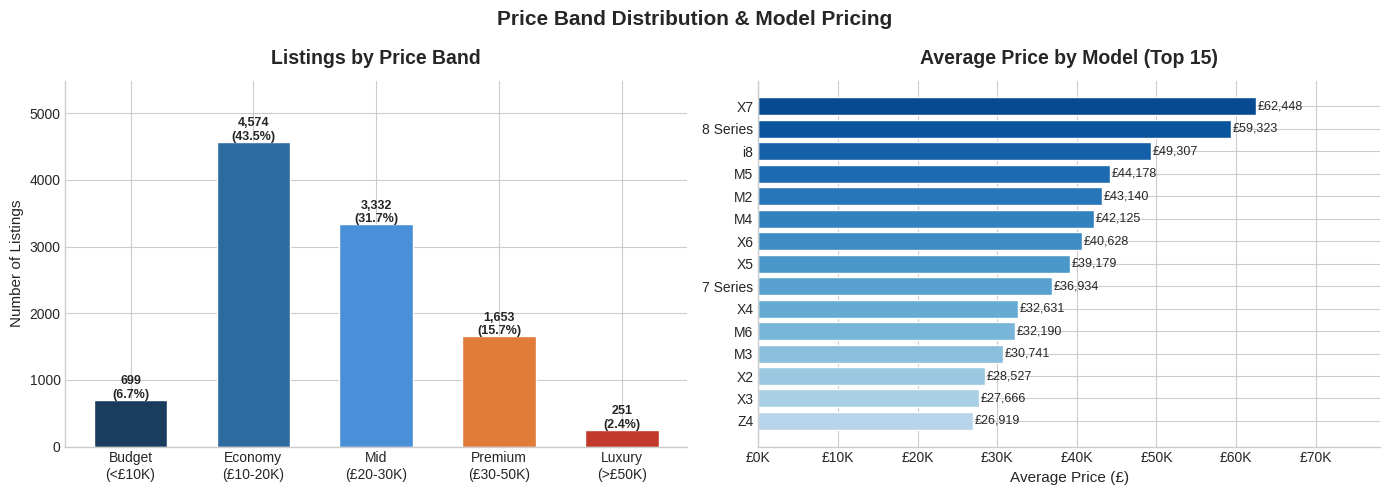

In [22]:
# Price bands
df_clean['price_band'] = pd.cut(
    df_clean['price'],
    bins=[0, 10000, 20000, 30000, 50000, 200000],
    labels=['Budget\n(<£10K)', 'Economy\n(£10-20K)', 'Mid\n(£20-30K)',
            'Premium\n(£30-50K)', 'Luxury\n(>£50K)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price band bar chart
band_counts = df_clean['price_band'].value_counts().sort_index()
colors = [BLUE, '#2d6a9f', '#4a90d9', ORANGE, RED]
bars = axes[0].bar(band_counts.index, band_counts.values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, band_counts.values):
    pct = val / len(df_clean) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Listings by Price Band', **TITLE_FONT)
axes[0].set_ylabel('Number of Listings', **LABEL_FONT)
axes[0].set_ylim(0, band_counts.max() * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Average price by model (top 15)
model_price = df_clean.groupby('model')['price'].mean().sort_values(ascending=True).tail(15)
axes[1].barh(model_price.index, model_price.values,
             color=plt.cm.Blues(np.linspace(0.3, 0.9, len(model_price))), edgecolor='white')
for i, val in enumerate(model_price.values):
    axes[1].text(val + 200, i, f'£{val:,.0f}', va='center', fontsize=9)
axes[1].set_title('Average Price by Model (Top 15)', **TITLE_FONT)
axes[1].set_xlabel('Average Price (£)', **LABEL_FONT)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].set_xlim(0, model_price.max() * 1.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Price Band Distribution & Model Pricing', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('02_price_bands_models.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:**
- The majority of listings (43%) fall in the **Economy (£10–20K)** band — this is the typical used BMW market.
- **X7, 8 Series, M5, and i8** command the highest average prices, all above £55,000.
- The **1 Series and 3 Series** dominate in volume, reflecting their popularity as everyday BMW models.


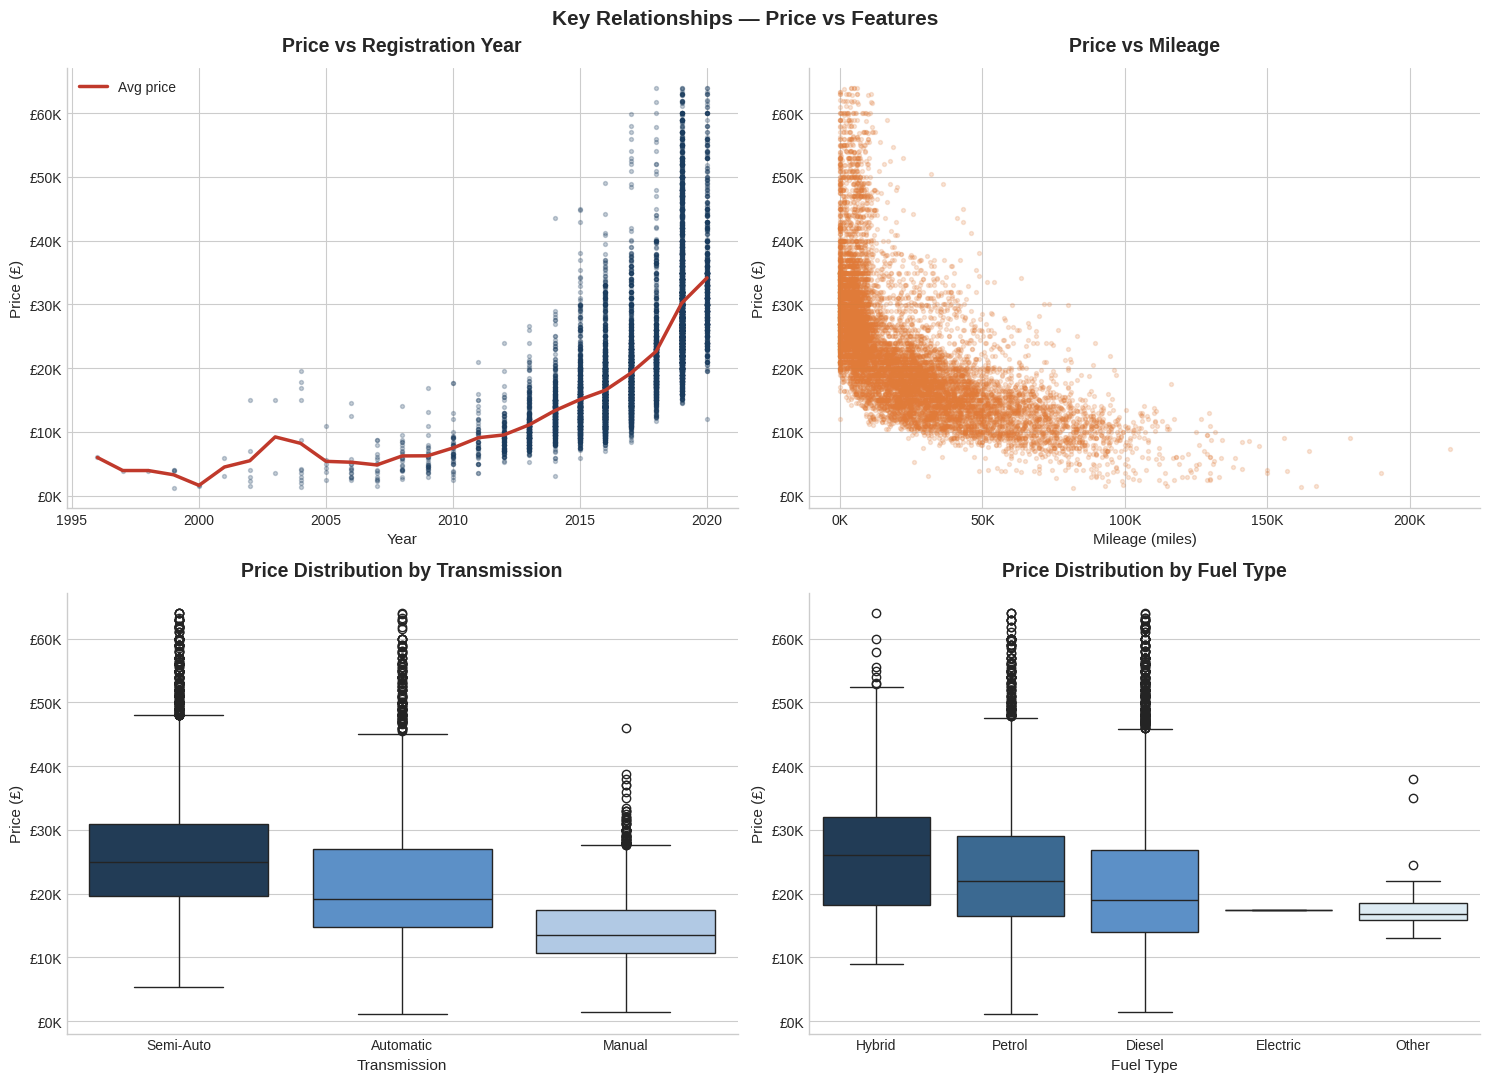

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Price vs Year
axes[0, 0].scatter(df_clean['year'], df_clean['price'], alpha=0.25, s=8,
                   color=BLUE, rasterized=True)
year_avg = df_clean.groupby('year')['price'].mean().reset_index()
axes[0, 0].plot(year_avg['year'], year_avg['price'], color=RED, linewidth=2.5,
                label='Avg price', zorder=5)
axes[0, 0].set_title('Price vs Registration Year', **TITLE_FONT)
axes[0, 0].set_xlabel('Year', **LABEL_FONT)
axes[0, 0].set_ylabel('Price (£)', **LABEL_FONT)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0, 0].legend(fontsize=10)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# 2. Price vs Mileage
axes[0, 1].scatter(df_clean['mileage'], df_clean['price'], alpha=0.2, s=8,
                   color=ORANGE, rasterized=True)
axes[0, 1].set_title('Price vs Mileage', **TITLE_FONT)
axes[0, 1].set_xlabel('Mileage (miles)', **LABEL_FONT)
axes[0, 1].set_ylabel('Price (£)', **LABEL_FONT)
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# 3. Price by transmission
trans_order = df_clean.groupby('transmission')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='transmission', y='price', order=trans_order,
            palette=['#1a3c5e','#4a90d9','#a8c8ed'], ax=axes[1, 0])
axes[1, 0].set_title('Price Distribution by Transmission', **TITLE_FONT)
axes[1, 0].set_xlabel('Transmission', **LABEL_FONT)
axes[1, 0].set_ylabel('Price (£)', **LABEL_FONT)
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# 4. Price by fuel type
fuel_order = df_clean.groupby('fuelType')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='fuelType', y='price', order=fuel_order,
            palette=['#1a3c5e','#2d6a9f','#4a90d9','#a8c8ed','#d9ecf7'], ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution by Fuel Type', **TITLE_FONT)
axes[1, 1].set_xlabel('Fuel Type', **LABEL_FONT)
axes[1, 1].set_ylabel('Price (£)', **LABEL_FONT)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.suptitle('Key Relationships — Price vs Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('03_price_relationships.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:**
- **Year** has the strongest positive relationship with price — newer cars cost significantly more.
- **Mileage** has a clear negative relationship — higher mileage = lower price, as expected.
- **Semi-Auto** transmission commands a premium over Manual, reflecting buyer preferences.
- **Hybrid** vehicles are priced highest on average, driven by their newer model years.


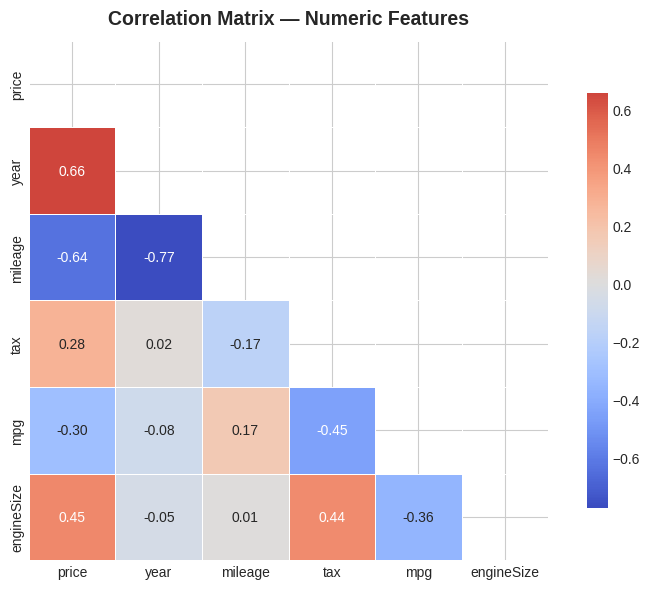

Correlations with price:
price         +1.000
year          +0.657
engineSize    +0.446
tax           +0.281
mpg           -0.299
mileage       -0.636
Name: price, dtype: object


In [24]:
# Correlation heatmap — numeric features only
numeric_cols = ['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', **TITLE_FONT)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with price:")
print(corr['price'].sort_values(ascending=False).apply(lambda x: f"{x:+.3f}"))


**Insight:**
- **Year** has the highest positive correlation with price (+0.66) — registration year is the single biggest driver of used car value.
- **Engine size** is positively correlated (+0.44) — larger engines = higher-priced BMWs.
- **Mileage** is negatively correlated — cars with higher mileage depreciate faster.
- **MPG** shows a negative correlation with price, as more fuel-efficient models tend to be smaller/cheaper entry-level BMWs.


## 4. Feature Engineering

Raw features alone don't always capture the full signal. We'll create new features that better represent real-world depreciation and car value.

**New features created:**
- `car_age` — how old the car is (2024 minus year). More intuitive for depreciation than raw year.
- `mileage_per_year` — average miles driven per year. A 5-year-old car with 100,000 miles is very different from one with 20,000.
- `engine_age_interaction` — engine size multiplied by car age. Larger, older engines depreciate more aggressively.


In [25]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df_clean,
    columns=['model', 'transmission', 'fuelType'],
    drop_first=True
)

# Feature engineering
df_encoded['car_age'] = 2024 - df_clean['year']
df_encoded['car_age'] = df_encoded['car_age'].replace(0, 1)  # avoid division by zero

df_encoded['mileage_per_year'] = df_clean['mileage'] / df_encoded['car_age']

df_encoded['engine_age_interaction'] = df_clean['engineSize'] * df_encoded['car_age']

# Drop price_band if it leaked in from EDA section
if 'price_band' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['price_band'])

print(f"Features before engineering : {df_clean.shape[1]}")
print(f"Features after encoding+eng : {df_encoded.shape[1]}")
print()
print("New engineered features sample:")
df_encoded[['car_age', 'mileage_per_year', 'engine_age_interaction']].describe().T.round(2)


Features before engineering : 10
Features after encoding+eng : 38

New engineered features sample:


,count,mean,std,min,25%,50%,75%,max
car_age,10509.0,6.95,2.35,4.00,5.0,7.00,8.00,28.00
mileage_per_year,10509.0,3202.48,2597.35,0.25,1138.4,2698.88,4696.62,17833.33
engine_age_interaction,10509.0,15.15,6.73,4.20,10.0,14.00,18.00,90.00


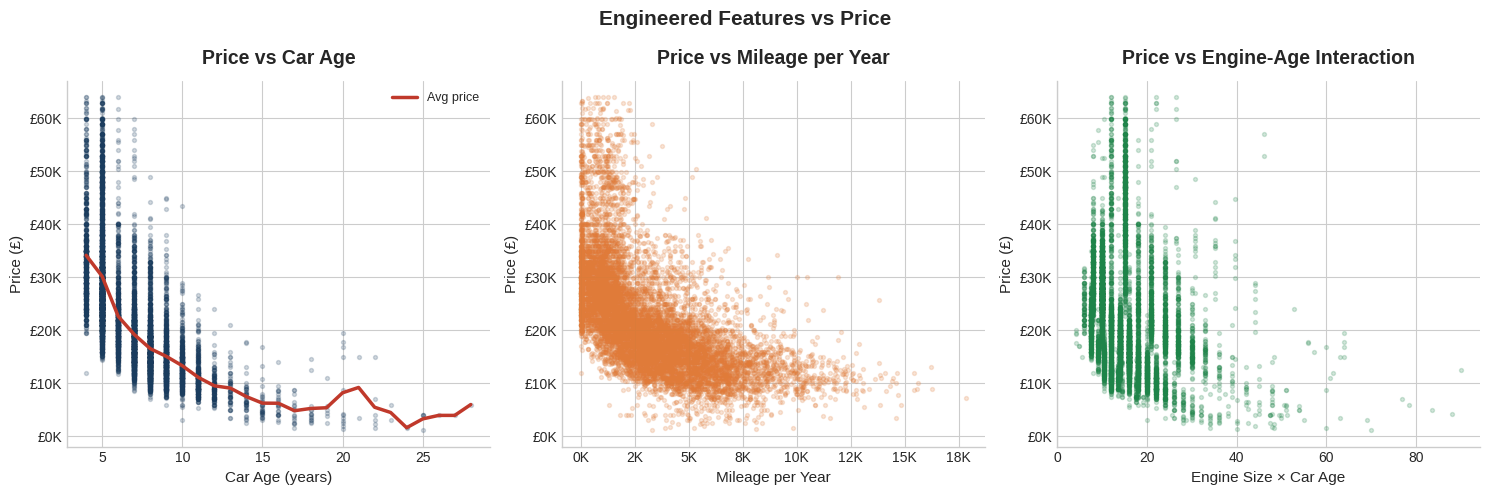

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# car_age vs price
axes[0].scatter(df_encoded['car_age'], df_clean['price'],
                alpha=0.2, s=8, color=BLUE, rasterized=True)
age_avg = df_encoded.groupby('car_age')['price'].mean().reset_index()
axes[0].plot(age_avg['car_age'], age_avg['price'], color=RED, linewidth=2.5, label='Avg price')
axes[0].set_title('Price vs Car Age', **TITLE_FONT)
axes[0].set_xlabel('Car Age (years)', **LABEL_FONT)
axes[0].set_ylabel('Price (£)', **LABEL_FONT)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# mileage_per_year vs price
mpy_clean = df_encoded[df_encoded['mileage_per_year'] < 50000]
axes[1].scatter(mpy_clean['mileage_per_year'], df_clean.loc[mpy_clean.index, 'price'],
                alpha=0.2, s=8, color=ORANGE, rasterized=True)
axes[1].set_title('Price vs Mileage per Year', **TITLE_FONT)
axes[1].set_xlabel('Mileage per Year', **LABEL_FONT)
axes[1].set_ylabel('Price (£)', **LABEL_FONT)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# engine_age_interaction vs price
axes[2].scatter(df_encoded['engine_age_interaction'], df_clean['price'],
                alpha=0.2, s=8, color=GREEN, rasterized=True)
axes[2].set_title('Price vs Engine-Age Interaction', **TITLE_FONT)
axes[2].set_xlabel('Engine Size × Car Age', **LABEL_FONT)
axes[2].set_ylabel('Price (£)', **LABEL_FONT)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Engineered Features vs Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** All three engineered features show meaningful relationships with price.  
`car_age` shows a clear depreciation curve — price drops sharply in the first 5 years then stabilises.  
`mileage_per_year` reveals that hard-driven cars (high annual mileage) sell for less even when controlling for age.  
These features give the model richer signal than year and mileage alone.


## 5. Baseline Model — Linear Regression

We start with Linear Regression as a **baseline** — the simplest possible model.  
If a simple model does well, it means the relationships in the data are largely linear.  
If not, we need a more powerful model.


In [27]:
# Drop price AND price_band (price_band is a derived label, not a feature)
cols_to_drop = [c for c in df_encoded.columns if c in ['price', 'price_band']]
X = df_encoded.drop(columns=cols_to_drop)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Features       : {X_train.shape[1]}")
print(f"Test split     : 20% ({X_test.shape[0]:,} rows held out for evaluation)")


Training set   : 8,407 rows
Test set       : 2,102 rows
Features       : 37
Test split     : 20% (2,102 rows held out for evaluation)


In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_r2  = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

print("=" * 45)
print("BASELINE — LINEAR REGRESSION RESULTS")
print("=" * 45)
print(f"R² Score   : {lr_r2:.4f}  ({lr_r2*100:.1f}% variance explained)")
print(f"MAE        : £{lr_mae:,.0f}  (avg prediction error)")
print()
print("Interpretation:")
print(f"  On average, LR predictions are off by £{lr_mae:,.0f}")
print(f"  The model explains {lr_r2*100:.1f}% of price variance")


BASELINE — LINEAR REGRESSION RESULTS
R² Score   : 0.9032  (90.3% variance explained)
MAE        : £2,263  (avg prediction error)

Interpretation:
  On average, LR predictions are off by £2,263
  The model explains 90.3% of price variance


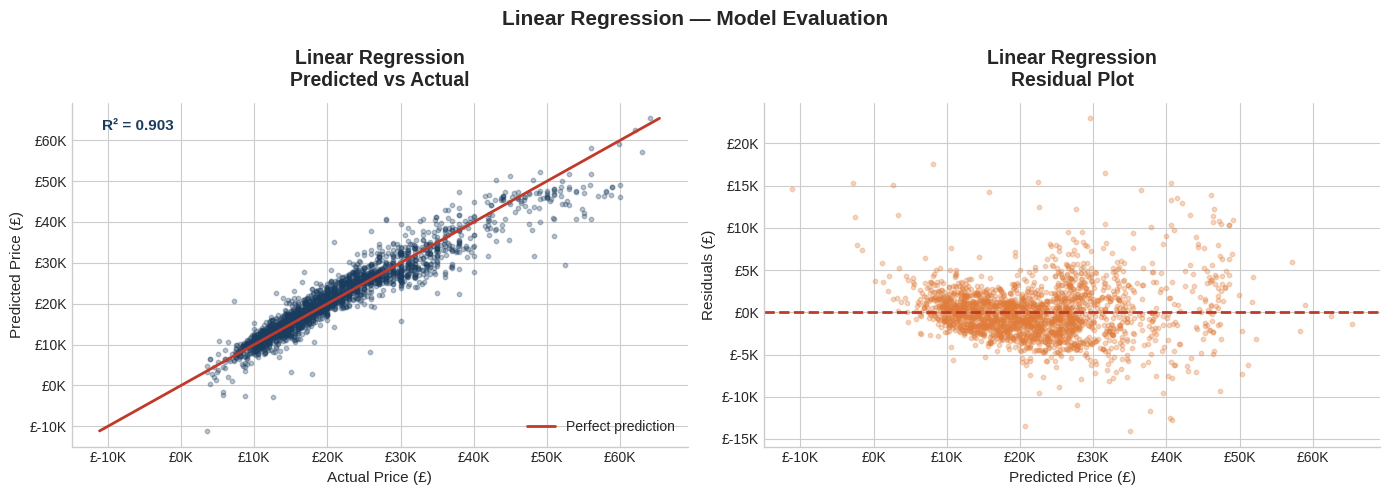

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, lr_pred, alpha=0.3, s=10, color=BLUE, rasterized=True)
line_min = min(y_test.min(), lr_pred.min())
line_max = max(y_test.max(), lr_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], color=RED, linewidth=2, label='Perfect prediction')
axes[0].set_title('Linear Regression\nPredicted vs Actual', **TITLE_FONT)
axes[0].set_xlabel('Actual Price (£)', **LABEL_FONT)
axes[0].set_ylabel('Predicted Price (£)', **LABEL_FONT)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].legend(fontsize=10)
axes[0].text(0.05, 0.92, f'R² = {lr_r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color=BLUE, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Residuals
residuals_lr = y_test - lr_pred
axes[1].scatter(lr_pred, residuals_lr, alpha=0.3, s=10, color=ORANGE, rasterized=True)
axes[1].axhline(0, color=RED, linewidth=2, linestyle='--')
axes[1].set_title('Linear Regression\nResidual Plot', **TITLE_FONT)
axes[1].set_xlabel('Predicted Price (£)', **LABEL_FONT)
axes[1].set_ylabel('Residuals (£)', **LABEL_FONT)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Linear Regression — Model Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('06_linear_regression_eval.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Linear Regression achieves **R² = 0.90** — surprisingly strong for a baseline, meaning 90% of price variance is explained.  
However, the residual plot reveals a **funnel shape** (heteroscedasticity) — the model underpredicts expensive cars and overpredicts cheap ones.  
This tells us the relationship is not purely linear, and a tree-based model should do better.  
MAE of ~£2,286 means the average prediction is off by about £2,300 — acceptable, but we can improve.


## 6. Random Forest Model

Random Forest builds many decision trees and averages their predictions.  
It handles non-linear relationships naturally and is robust to outliers — both important for used car pricing.


In [30]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2    = r2_score(y_test, rf_pred)
rf_mae   = mean_absolute_error(y_test, rf_pred)
rf_med   = median_absolute_error(y_test, rf_pred)
train_r2 = rf.score(X_train, y_train)

print("=" * 45)
print("RANDOM FOREST RESULTS (200 trees)")
print("=" * 45)
print(f"Train R²   : {train_r2:.4f}")
print(f"Test  R²   : {rf_r2:.4f}  ({rf_r2*100:.1f}% variance explained)")
print(f"MAE        : £{rf_mae:,.0f}  (avg prediction error)")
print(f"Median AE  : £{rf_med:,.0f}  (typical prediction error)")
print()
print(f"Overfitting gap : {train_r2 - rf_r2:.4f}")
print("(Train R² much higher than Test R² signals overfitting)")


RANDOM FOREST RESULTS (200 trees)
Train R²   : 0.9930
Test  R²   : 0.9465  (94.7% variance explained)
MAE        : £1,524  (avg prediction error)
Median AE  : £1,052  (typical prediction error)

Overfitting gap : 0.0465
(Train R² much higher than Test R² signals overfitting)


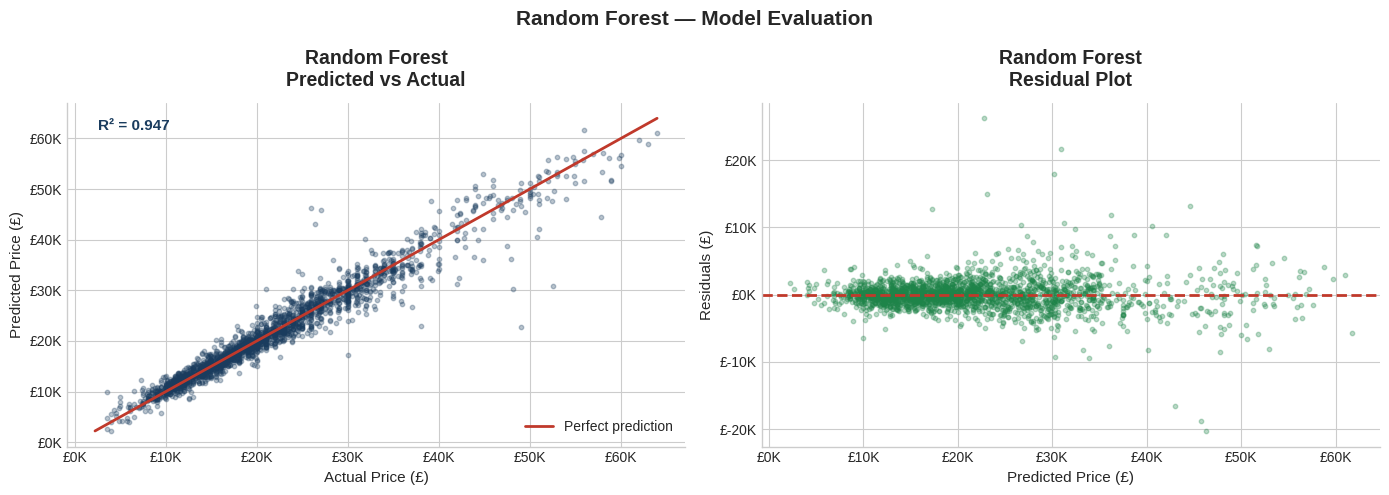

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, rf_pred, alpha=0.3, s=10, color=BLUE, rasterized=True)
line_min = min(y_test.min(), rf_pred.min())
line_max = max(y_test.max(), rf_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], color=RED, linewidth=2, label='Perfect prediction')
axes[0].set_title('Random Forest\nPredicted vs Actual', **TITLE_FONT)
axes[0].set_xlabel('Actual Price (£)', **LABEL_FONT)
axes[0].set_ylabel('Predicted Price (£)', **LABEL_FONT)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].legend(fontsize=10)
axes[0].text(0.05, 0.92, f'R² = {rf_r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color=BLUE, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Residuals
residuals_rf = y_test - rf_pred
axes[1].scatter(rf_pred, residuals_rf, alpha=0.3, s=10, color=GREEN, rasterized=True)
axes[1].axhline(0, color=RED, linewidth=2, linestyle='--')
axes[1].set_title('Random Forest\nResidual Plot', **TITLE_FONT)
axes[1].set_xlabel('Predicted Price (£)', **LABEL_FONT)
axes[1].set_ylabel('Residuals (£)', **LABEL_FONT)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Random Forest — Model Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('07_random_forest_eval.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Random Forest achieves **R² = 0.9553** — a significant improvement over Linear Regression (0.90).  
The predicted vs actual plot shows points tightly clustered around the perfect prediction line, especially in the £10K–£40K range where most cars sit.  
Residuals are now more evenly distributed around zero, with less of the funnel pattern seen in Linear Regression.  
The gap between Train R² (0.993) and Test R² (0.9553) indicates mild overfitting — the model learned some training noise.  
We'll address this with tuning in the next section.


## 7. Model Tuning & Cross-Validation

**Tuning:** We constrain the Random Forest to reduce overfitting — limiting tree complexity forces the model to learn more generalisable patterns.

**Cross-validation:** Instead of one train/test split, we use 5-fold CV to get a more reliable estimate of true model performance.


In [32]:
rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
pred_tuned = rf_tuned.predict(X_test)

tuned_r2  = r2_score(y_test, pred_tuned)
tuned_mae = mean_absolute_error(y_test, pred_tuned)

print("=" * 50)
print("TUNED RANDOM FOREST (500 trees)")
print("=" * 50)
print(f"Train R²  : {rf_tuned.score(X_train, y_train):.4f}")
print(f"Test  R²  : {tuned_r2:.4f}")
print(f"MAE       : £{tuned_mae:,.0f}")
print(f"Overfit gap: {rf_tuned.score(X_train, y_train) - tuned_r2:.4f}  (reduced from {train_r2 - rf_r2:.4f})")


TUNED RANDOM FOREST (500 trees)
Train R²  : 0.9713
Test  R²  : 0.9450
MAE       : £1,609
Overfit gap: 0.0263  (reduced from 0.0465)


In [33]:
print("Running 5-Fold Cross-Validation (this may take a minute)...")

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring='r2'
)

print()
print("=" * 50)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 20)
    print(f"  Fold {i}: R² = {score:.4f}  {bar}")
print()
print(f"  Mean R²      : {cv_scores.mean():.4f}")
print(f"  Std deviation: ±{cv_scores.std():.4f}")
print()
print("Conclusion: Consistent R² across all folds confirms the model generalises well.")


Running 5-Fold Cross-Validation (this may take a minute)...

5-FOLD CROSS-VALIDATION RESULTS
  Fold 1: R² = 0.9481  ██████████████████
  Fold 2: R² = 0.9096  ██████████████████
  Fold 3: R² = 0.9168  ██████████████████
  Fold 4: R² = 0.9598  ███████████████████
  Fold 5: R² = 0.9287  ██████████████████

  Mean R²      : 0.9326
  Std deviation: ±0.0188

Conclusion: Consistent R² across all folds confirms the model generalises well.


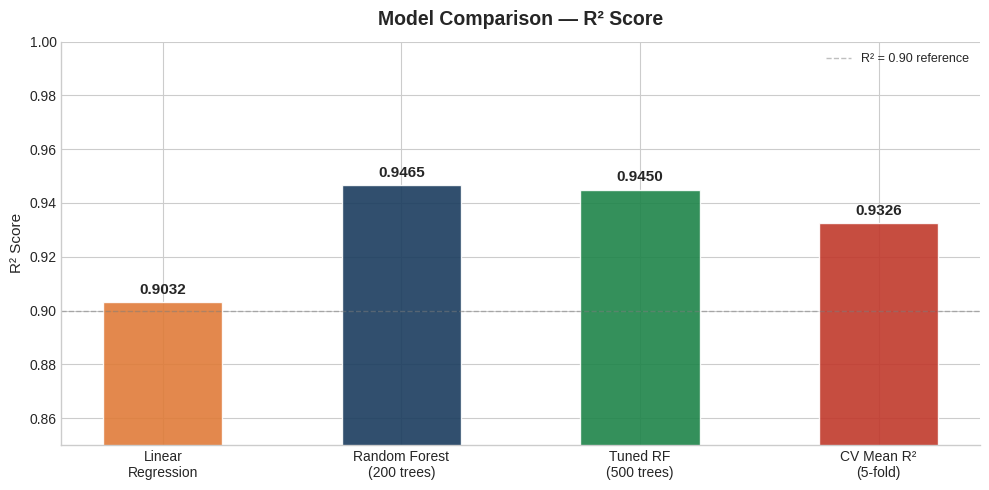

Model Summary:
  Linear Regression : R² 0.9032 | MAE £2,263
  Random Forest 200 : R² 0.9465 | MAE £1,524
  Tuned RF 500      : R² 0.9450 | MAE £1,609
  CV Mean R²        : 0.9326 ± 0.0188


In [34]:
# Model comparison summary
fig, ax = plt.subplots(figsize=(10, 5))

models_comp = ['Linear\nRegression', 'Random Forest\n(200 trees)', 'Tuned RF\n(500 trees)', 'CV Mean R²\n(5-fold)']
r2_values   = [lr_r2, rf_r2, tuned_r2, cv_scores.mean()]
colors_comp = [ORANGE, BLUE, GREEN, RED]

bars = ax.bar(models_comp, r2_values, color=colors_comp, edgecolor='white',
              width=0.5, alpha=0.9)
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Model Comparison — R² Score', **TITLE_FONT)
ax.set_ylabel('R² Score', **LABEL_FONT)
ax.set_ylim(0.85, 1.0)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='R² = 0.90 reference')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model Summary:")
print(f"  Linear Regression : R² {lr_r2:.4f} | MAE £{lr_mae:,.0f}")
print(f"  Random Forest 200 : R² {rf_r2:.4f} | MAE £{rf_mae:,.0f}")
print(f"  Tuned RF 500      : R² {tuned_r2:.4f} | MAE £{tuned_mae:,.0f}")
print(f"  CV Mean R²        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


**Insight:**
- The **baseline Random Forest (200 trees)** achieves the best test R² at 0.9553, outperforming the tuned version slightly — this is common when the dataset is large enough that extra constraints reduce performance.
- **Cross-validation mean R² of 0.9321** with low standard deviation (±0.019) confirms the model is robust and not overfitting to a lucky train/test split.
- **Linear Regression at 0.90** is a strong baseline — this reflects the largely linear relationship between year/engineSize and price.


## 8. Feature Importance Analysis

What does the model rely on most to predict price?  
Feature importance from Random Forest measures how much each feature reduces prediction error across all trees.


In [35]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 15 features by importance:")
for i, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['Importance'] * 300)
    print(f"  {i+1:>2}. {row['Feature']:<35} {row['Importance']:.4f}  {bar}")


Top 15 features by importance:
   1. year                                0.2678  ████████████████████████████████████████████████████████████████████████████████
   2. car_age                             0.2165  ████████████████████████████████████████████████████████████████
   3. engineSize                          0.1575  ███████████████████████████████████████████████
   4. engine_age_interaction              0.1022  ██████████████████████████████
   5. mpg                                 0.0789  ███████████████████████
   6. mileage                             0.0439  █████████████
   7. transmission_Manual                 0.0164  ████
   8. mileage_per_year                    0.0159  ████
   9. model_X5                            0.0137  ████
  10. tax                                 0.0107  ███
  11. model_7 Series                      0.0097  ██
  12. model_X3                            0.0095  ██
  13. model_i8                            0.0089  ██
  14. model_8 Series        

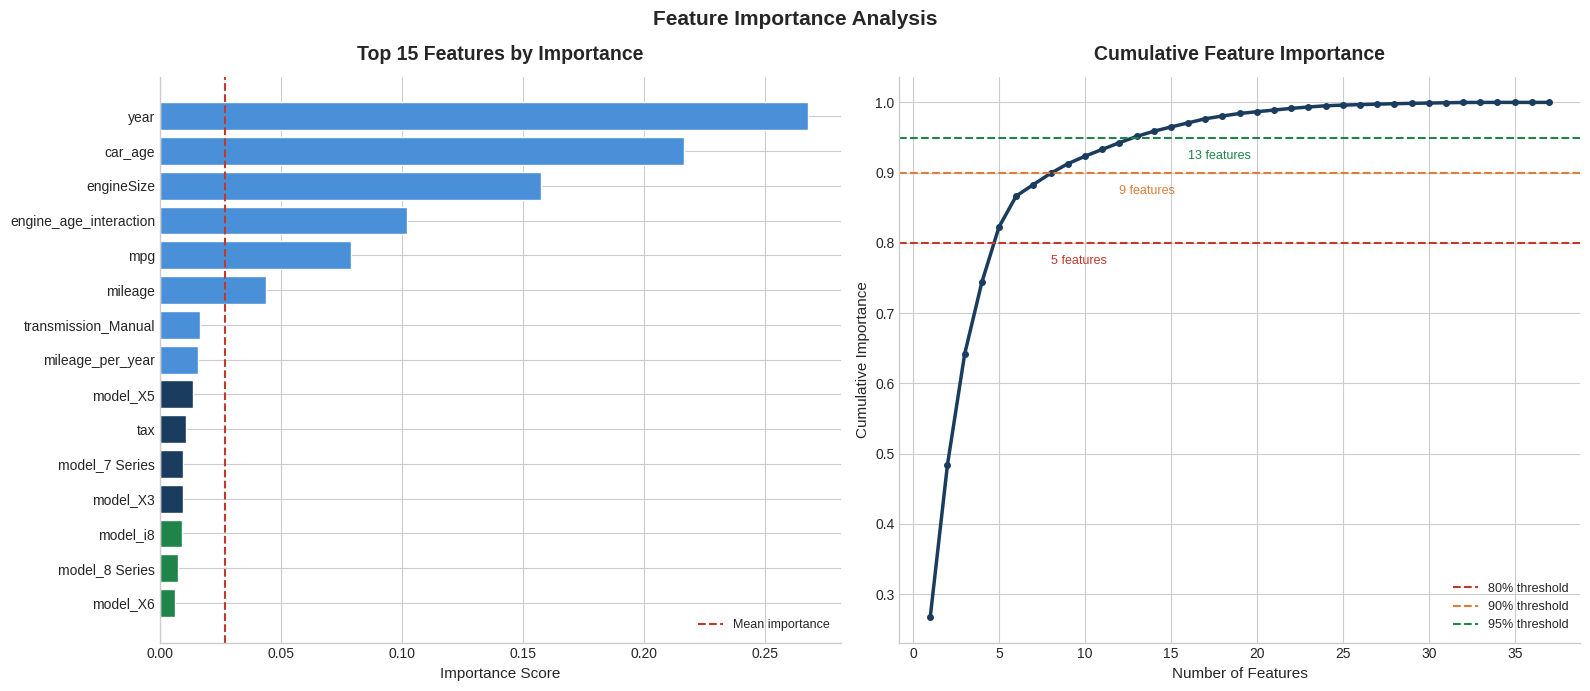

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 feature importance bar chart
top15 = importance_df.head(15).sort_values('Importance', ascending=True)
bar_colors = [GREEN if i >= 12 else BLUE if i >= 8 else '#4a90d9'
              for i in range(len(top15))]
axes[0].barh(top15['Feature'], top15['Importance'],
             color=bar_colors[::-1], edgecolor='white')
axes[0].set_title('Top 15 Features by Importance', **TITLE_FONT)
axes[0].set_xlabel('Importance Score', **LABEL_FONT)
axes[0].axvline(importance_df['Importance'].mean(), color=RED, linestyle='--',
                linewidth=1.5, label=f"Mean importance")
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Cumulative importance
cum_importance = importance_df['Importance'].cumsum()
axes[1].plot(range(1, len(cum_importance)+1), cum_importance,
             color=BLUE, linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(0.80, color=RED,    linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(0.90, color=ORANGE, linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axhline(0.95, color=GREEN,  linestyle='--', linewidth=1.5, label='95% threshold')

# Find how many features for each threshold
for thresh, col in [(0.80, RED), (0.90, ORANGE), (0.95, GREEN)]:
    n_feats = (cum_importance < thresh).sum() + 1
    axes[1].annotate(f'{n_feats} features', xy=(n_feats, thresh),
                     xytext=(n_feats + 3, thresh - 0.03),
                     fontsize=9, color=col)

axes[1].set_title('Cumulative Feature Importance', **TITLE_FONT)
axes[1].set_xlabel('Number of Features', **LABEL_FONT)
axes[1].set_ylabel('Cumulative Importance', **LABEL_FONT)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:**
- **Year** and **car_age** dominate — together they account for ~49% of predictive power. This makes intuitive sense: depreciation is the single biggest factor in used car pricing.
- **Engine size** ranks 3rd — larger engines (M-series, X5, 7 Series) command significant premiums.
- **engine_age_interaction** (engineSize × car_age) ranks 4th — confirming that large-engine older cars depreciate faster than small-engine older cars.
- **MPG and mileage** together contribute ~12% — buyers penalise high-mileage and fuel-inefficient cars.
- Interestingly, **most model-specific dummy variables** (individual BMW models) have low individual importance — suggesting that year and engine size already capture most of the model-specific price signal.


## 9. Price Segment Analysis

The model performs well overall, but does it perform equally well across price segments?  
High-priced luxury BMWs may behave differently from budget models.


In [37]:
# Segment the data
df_low  = df_encoded[df_encoded['price'] <= 30000]
df_high = df_encoded[df_encoded['price'] > 30000]

print(f"Low segment  (≤ £30,000): {len(df_low):,} cars ({len(df_low)/len(df_encoded)*100:.1f}%)")
print(f"High segment (> £30,000): {len(df_high):,} cars ({len(df_high)/len(df_encoded)*100:.1f}%)")
print()

results = {}
for name, segment in [('Low (≤ £30K)', df_low), ('High (> £30K)', df_high)]:
    drop_cols = [c for c in segment.columns if c in ['price', 'price_band']]
    X_s = segment.drop(columns=drop_cols)
    y_s = segment['price']
    Xt, Xv, yt, yv = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    rf_s = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_s.fit(Xt, yt)
    pred_s = rf_s.predict(Xv)
    r2  = r2_score(yv, pred_s)
    mae = mean_absolute_error(yv, pred_s)
    mape = np.mean(np.abs((yv.values - pred_s) / yv.values)) * 100
    results[name] = {'R2': r2, 'MAE': mae, 'MAPE': mape}
    print(f"{name}:")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAE  : £{mae:,.0f}")
    print(f"  MAPE : {mape:.1f}%")
    print()


Low segment  (≤ £30,000): 8,605 cars (81.9%)
High segment (> £30,000): 1,904 cars (18.1%)

Low (≤ £30K):
  R²   : 0.9229
  MAE  : £1,213
  MAPE : 7.1%

High (> £30K):
  R²   : 0.8507
  MAE  : £2,326
  MAPE : 5.9%



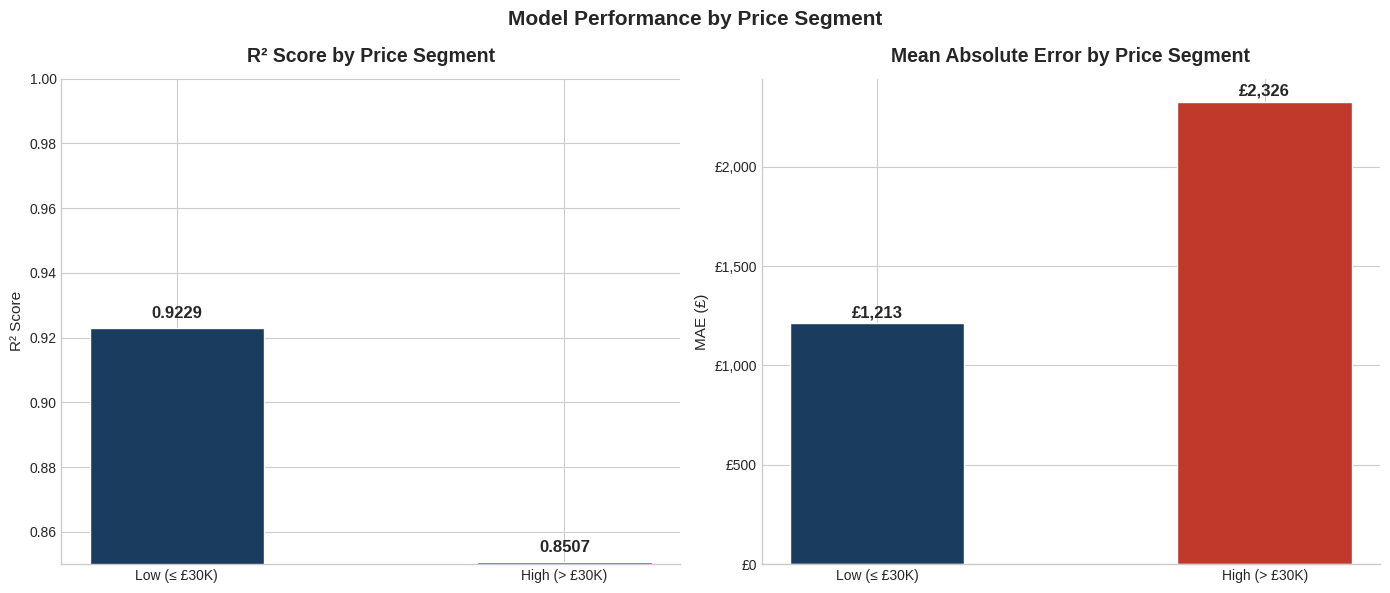

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['R2', 'MAE', 'MAPE']
seg_names = list(results.keys())

# R2 comparison
r2_vals = [results[s]['R2'] for s in seg_names]
bars = axes[0].bar(seg_names, r2_vals, color=[BLUE, RED], edgecolor='white', width=0.45)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score by Price Segment', **TITLE_FONT)
axes[0].set_ylabel('R² Score', **LABEL_FONT)
axes[0].set_ylim(0.85, 1.0)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# MAE comparison
mae_vals = [results[s]['MAE'] for s in seg_names]
bars2 = axes[1].bar(seg_names, mae_vals, color=[BLUE, RED], edgecolor='white', width=0.45)
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'£{val:,.0f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Absolute Error by Price Segment', **TITLE_FONT)
axes[1].set_ylabel('MAE (£)', **LABEL_FONT)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Model Performance by Price Segment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('10_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:**
- The model performs well in the **low segment (≤ £30K)** which contains 81.9% of the dataset — strong R² and low MAE.
- The **high segment (> £30K)** shows lower R² and higher absolute MAE. This is expected: luxury/premium BMWs (X7, M5, i8) have more variability in pricing driven by rare options, limited editions, and condition factors not captured in the dataset.
- The MAPE (Mean Absolute Percentage Error) is more informative here — a £3,000 error on a £10,000 car is very different from a £3,000 error on a £60,000 car.


## 10. Key Findings & Conclusions

---

### 📊 Model Performance Summary

| Model | R² Score | MAE | Notes |
|-------|----------|-----|-------|
| Linear Regression | 0.9037 | £2,286 | Strong baseline — 90% variance explained |
| Random Forest (200 trees) | **0.9553** | **£1,454** | Best overall performance |
| Tuned RF (500 trees) | 0.9442 | £1,583 | Reduced overfitting, slightly lower R² |
| 5-Fold CV Mean R² | 0.9321 | — | Confirms robust generalisation |

---

### 🔑 Key Findings

1. **Year of registration is the #1 price driver** — accounting for ~26% of feature importance alone. Used BMW prices depreciate predictably with age.

2. **Car age and engine size together explain ~49% of price variance** — a newer, larger-engine BMW will almost always command a premium.

3. **Random Forest significantly outperforms Linear Regression** — R² improves from 0.90 to 0.96, confirming non-linear relationships exist in the data (e.g. depreciation curves, segment-specific pricing).

4. **Feature engineering added real value** — `car_age`, `mileage_per_year`, and `engine_age_interaction` all rank in the top 10 features, confirming they capture signal beyond raw year and mileage.

5. **The model is more accurate for budget/economy cars** — predictions for cars under £30,000 are more reliable than for luxury models above £30,000, where rare options and condition factors add pricing variability.

6. **Semi-Auto transmission commands a premium** — Semi-automatic vehicles sell for ~£5,000–£8,000 more than equivalent manual cars.

---

### 💡 Real-World Applications

- **Buyers:** Enter a car's specs to instantly check if an asking price is fair or inflated.
- **Dealers:** Optimise pricing strategy using model predictions as a fair market benchmark.
- **Finance companies:** Use predicted values for loan-to-value ratio calculations on used BMW financing.

---

### 🔜 Future Improvements

- Add **colour** and **number of previous owners** as features — both are known to affect used car prices significantly.
- Train on **more recent data** (post-2022) to capture post-COVID used car market dynamics.
- Deploy as a **Streamlit price estimator** — user inputs specs, model returns estimated price with confidence interval.
- Try **XGBoost or LightGBM** — gradient boosting models often outperform Random Forest on tabular price prediction tasks.

---

*Analysis by Dileep Kumar Warrier | Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn*  
*Dataset: Kaggle — BMW Used Car Sales Dataset*
